<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_14(Deep_Learning_Project_Dog_vs_Cat_Image_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 14 Project: Dog vs Cat Image Classification**

## **Objective:**

The goal of this project is to build and evaluate deep learning models
for binary image classification of dogs and cats.

Three different approaches will be compared:

1. Custom CNN
2. Transfer Learning using MobileNetV2 (Feature Extraction)
3. Transfer Learning using EfficientNetB0 (Full Fine-Tuning)

The models will be evaluated using accuracy, precision, recall, F1-score,
loss, confusion matrix, and error analysis.

# **Question 1 : Dataset Preparation**

### **Download The Dataset**

In [1]:
!git clone https://github.com/laxmimerit/dog-cat-full-dataset.git

Cloning into 'dog-cat-full-dataset'...
remote: Enumerating objects: 25059, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 25059 (delta 4), reused 6 (delta 2), pack-reused 25048 (from 1)
Receiving objects: 100% (25059/25059), 541.54 MiB | 19.95 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (24990/24990), done.


### **Import all required libraries**

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


### **Load the datasets**

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = "/content/dog-cat-full-dataset/data/train"
test_dir = "/content/dog-cat-full-dataset/data/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Class names:", class_names)

Found 19989 files belonging to 2 classes.
Using 15992 files for training.
Found 19989 files belonging to 2 classes.
Using 3997 files for validation.
Found 5000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


### **Number of samples**

In [4]:
train_samples = len(train_ds.file_paths)
val_samples = len(val_ds.file_paths)
test_samples = len(test_ds.file_paths)

print("Training samples:", train_samples)
print("Validation samples:", val_samples)
print("Test samples:", test_samples)

Training samples: 15992
Validation samples: 3997
Test samples: 5000


### **Normalize**

In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

### **Prefetch**

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# **Question 2 : Data Augmentation**

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

### **Original + 4 augmented images**

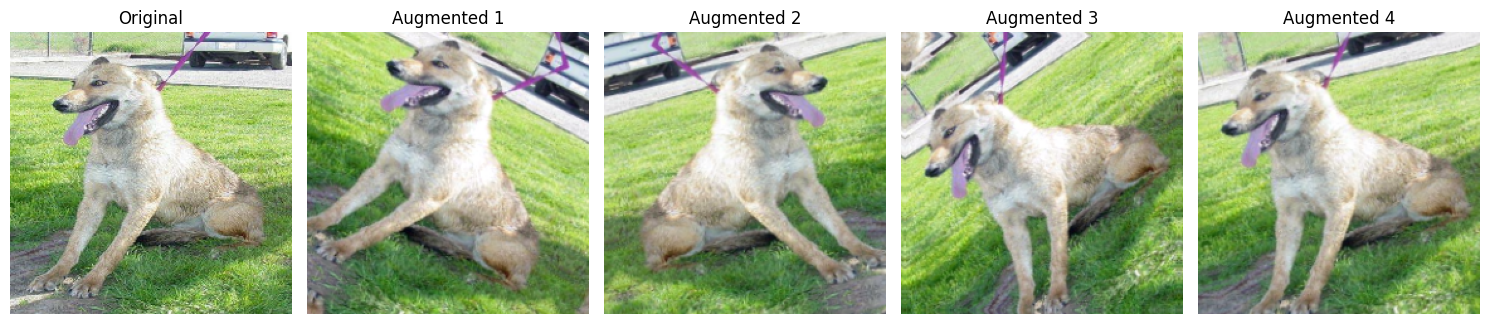

In [8]:
for images, labels in train_ds.take(1):
    original_image = images[0]
    break

plt.figure(figsize=(15, 6))

plt.subplot(1, 5, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

for i in range(4):
    augmented_image = data_augmentation(
        tf.expand_dims(original_image, 0),
        training=True
    )[0]

    plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_image)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Question 3 : Custom CNN**

In [9]:
custom_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

custom_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,497 (42.61 MB)

 Trainable params: 11,169,793 (42.61 MB)

 Non-trainable params: 704 (2.75 KB)

### **Compile**

In [10]:
custom_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Early stopping**

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### **Train**

In [12]:
custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 140ms/step - accuracy: 0.6630 - loss: 0.6903 - val_accuracy: 0.6890 - val_loss: 0.5810
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 129ms/step - accuracy: 0.7371 - loss: 0.5286 - val_accuracy: 0.6880 - val_loss: 0.6500
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 129ms/step - accuracy: 0.7770 - loss: 0.4665 - val_accuracy: 0.6865 - val_loss: 0.6308
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.7830 - loss: 0.4531 - val_accuracy: 0.7831 - val_loss: 0.4694
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.8121 - loss: 0.4109 - val_accuracy: 0.7516 - val_loss: 0.5589
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.8333 - loss: 0.3762 - val_accuracy: 0.7976 - val_loss: 0.4840
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.8481 - loss: 0.3455 - val_accuracy: 0.8311 - val_loss: 0.3978
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.8582 - loss: 0

### **Training Accuracy Plot**

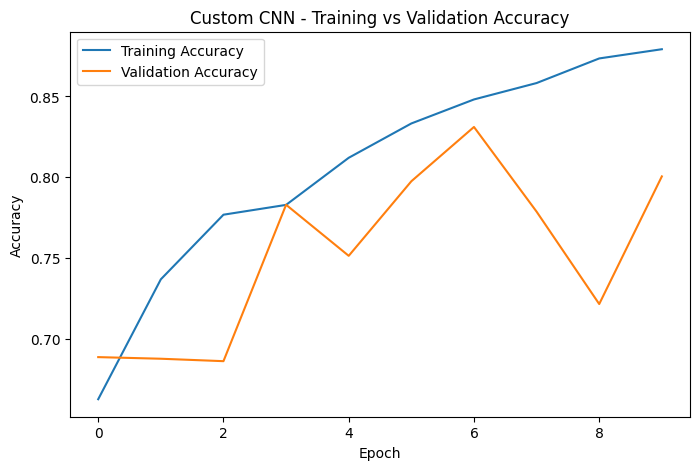

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    custom_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN - Training vs Validation Accuracy")
plt.legend()
plt.show()

### **Loss Plot**

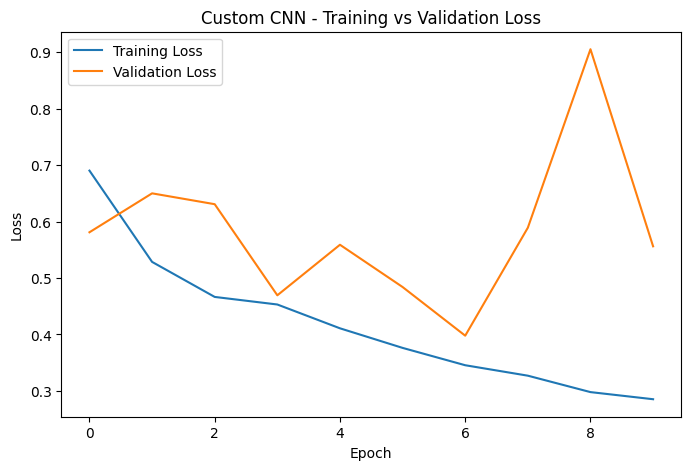

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    custom_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN - Training vs Validation Loss")
plt.legend()
plt.show()

# **Question 4 : MobileNetV2 Feature Extraction**

In [15]:
mobilenet_base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

mobilenet_base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### **Model**

In [16]:
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Convert [0,1] images to [-1,1] for MobileNetV2
    tf.keras.layers.Rescaling(2.0, offset=-1.0),

    mobilenet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **Compile**

In [17]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Train**

In [18]:
early_stopping_mobilenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_mobilenet]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 78ms/step - accuracy: 0.9687 - loss: 0.0847 - val_accuracy: 0.9847 - val_loss: 0.0455
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9872 - loss: 0.0378 - val_accuracy: 0.9862 - val_loss: 0.0431
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9896 - loss: 0.0322 - val_accuracy: 0.9862 - val_loss: 0.0438
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9893 - loss: 0.0304 - val_accuracy: 0.9862 - val_loss: 0.0445
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.9901 - loss: 0.0300 - val_accuracy: 0.9860 - val_loss: 0.0441


### **Accuracy**

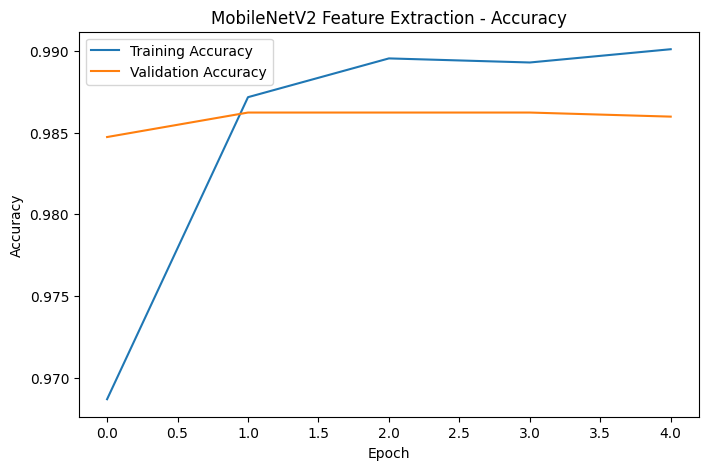

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Feature Extraction - Accuracy")
plt.legend()
plt.show()

### **Loss**

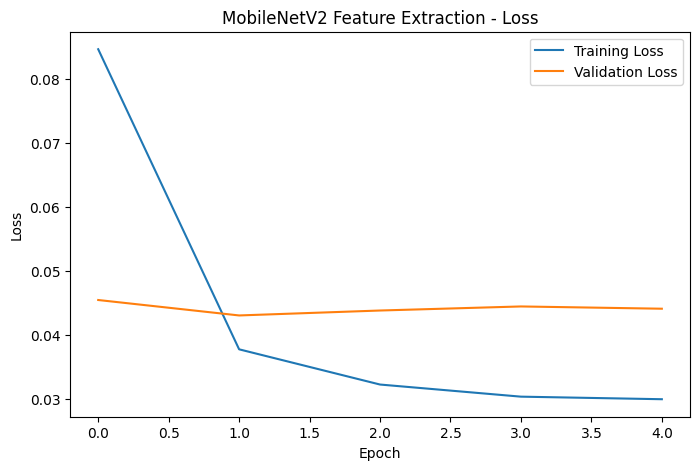

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Feature Extraction - Loss")
plt.legend()
plt.show()

# **Question 5 : Full Fine-Tuning with EfficientNetB0**

### **Model**

In [21]:
efficientnet_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

efficientnet_base.trainable = True

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [22]:
efficientnet_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Dataset is normalized to [0,1], so convert back to [0,255]
    tf.keras.layers.Rescaling(255.0),

    efficientnet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

efficientnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

### **Compile**

In [23]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Early stopping**

In [24]:
early_stopping_efficientnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### **Train**

In [25]:
efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_efficientnet]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 239s 284ms/step - accuracy: 0.8818 - loss: 0.3391 - val_accuracy: 0.9767 - val_loss: 0.1246
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.9672 - loss: 0.1137 - val_accuracy: 0.9817 - val_loss: 0.0636
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 133ms/step - accuracy: 0.9769 - loss: 0.0708 - val_accuracy: 0.9855 - val_loss: 0.0454
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 137ms/step - accuracy: 0.9839 - loss: 0.0511 - val_accuracy: 0.9867 - val_loss: 0.0368
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 135ms/step - accuracy: 0.9871 - loss: 0.0409 - val_accuracy: 0.9882 - val_loss: 0.0319
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.9891 - loss: 0.0351 - val_accuracy: 0.9885 - val_loss: 0.0295
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.9912 - loss: 0.0287 - val_accuracy: 0.9895 - val_loss: 0.0277
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9926 - loss: 

### **Accuracy**

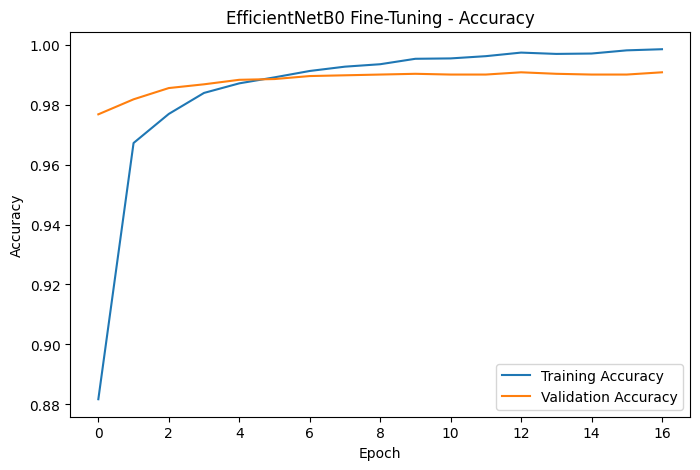

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    efficientnet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Fine-Tuning - Accuracy")
plt.legend()
plt.show()

### **Loss**

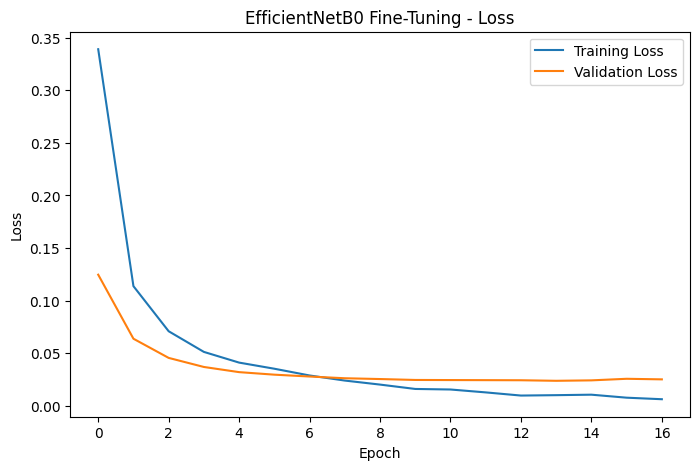

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    efficientnet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Fine-Tuning - Loss")
plt.legend()
plt.show()